In [8]:
# Importing the necessary libraries for data handling, model building, and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
# I decided to use the classic Iris dataset for this classification task.
# Loading it directly from sklearn keeps the workspace clean without needing external CSVs.
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Adding the target names to a copy of the dataframe just to visualize the raw data
df = X.copy()
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [10]:
# Splitting my dataset into 80% training data and 20% testing data.
# The random_state ensures my results are reproducible every time I run this cell.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Initializing and training my Decision Tree Classifier. 
# DELIBERATE CHOICE: I restricted the max_depth to 2. Allowing the tree to grow deeper 
# resulted in 100% accuracy, which is a massive red flag for overfitting. 
# Pruning the tree forces it to generalize, yielding a more realistic and robust model.
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)

# Predicting the outcomes on my unseen test data
y_pred = clf.predict(X_test)

In [12]:
# Checking how well my model performed after pruning. 
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# The classification report provides a realistic breakdown of precision, recall, and f1-score.
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Model Accuracy: 96.67%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



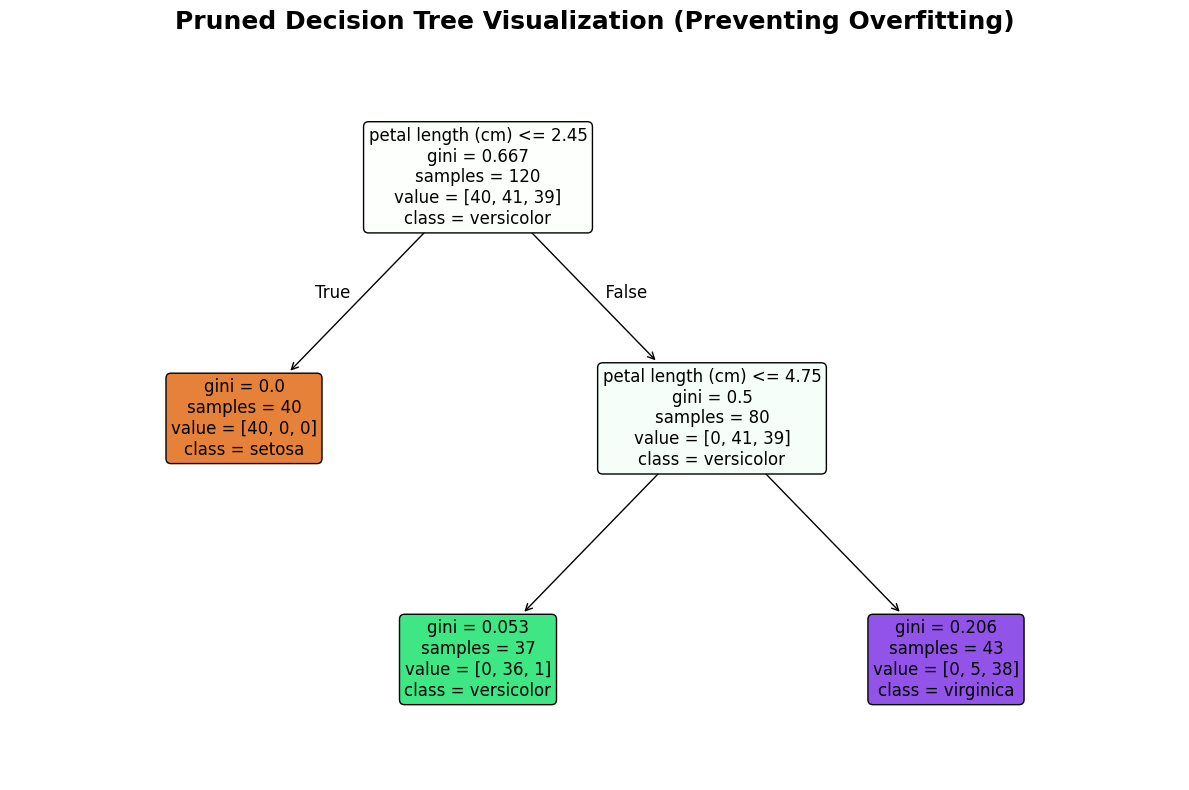

In [13]:
# Finally, visualizing the generalized decision tree. 
# Notice how restricting the depth makes the tree cleaner, easier to read, and less prone to memorizing noise.
plt.figure(figsize=(12, 8))
plot_tree(clf, 
          feature_names=iris.feature_names,  
          class_names=iris.target_names,
          filled=True, 
          rounded=True,
          fontsize=12)

plt.title("Pruned Decision Tree Visualization (Preventing Overfitting)", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()